In [1]:
# evaluation.ipynb

# =====================
# 1. Import libraries
# =====================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Plot 스타일
sns.set(style="whitegrid", font_scale=1.2)

In [2]:
import glob
import os

def get_latest_file(base_dir: str, filename: str) -> str:
    """주어진 base_dir 하위의 가장 최신 날짜 폴더에서 filename 경로 반환"""
    subdirs = glob.glob(os.path.join(base_dir, "20*"))  # 20으로 시작하는 날짜 폴더
    if not subdirs:
        raise FileNotFoundError(f"No subdirectories found in {base_dir}")
    latest_dir = max(subdirs, key=os.path.getmtime)
    return os.path.join(latest_dir, filename)

# -------- 사용 예시 --------
# training log 자동 선택
log_path = get_latest_file("./unet/runs/SIMBA_Mtot", "training_log.csv")

# prediction 결과 자동 선택
pred_path = get_latest_file("./unet/predictions/SIMBA_Mtot", "predictions.csv")

print("Latest training log:", log_path)
print("Latest predictions :", pred_path)


Latest training log: ./unet/runs/SIMBA_Mtot/20250819_201537/training_log.csv
Latest predictions : ./unet/predictions/SIMBA_Mtot/20250819_201723/predictions.csv


,epoch,train_loss,val_loss,lr
0,1,0.067707,0.017895,0.0001
1,2,0.012104,0.018373,0.0001
2,3,0.008349,0.019601,0.0001
3,4,0.006266,0.005467,0.0001
4,5,0.005259,0.004614,0.0001


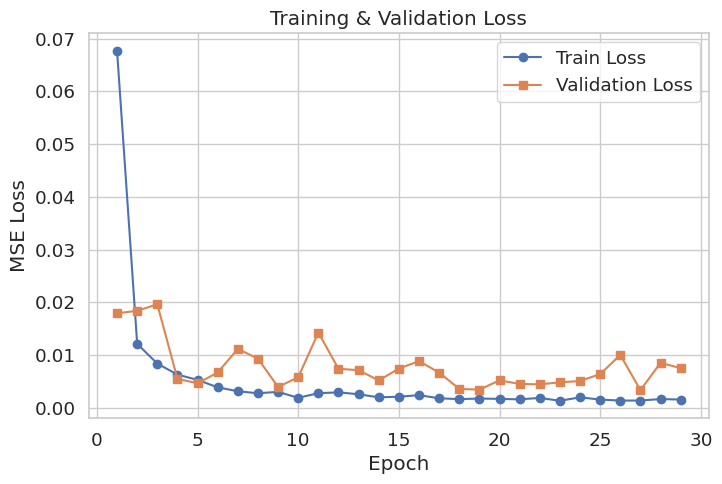

In [3]:
# =====================
# 2. Load training log
# =====================
#log_path = "./unet/runs/SIMBA_Mtot/20250819_141929/training_log.csv"  # <- 실제 경로로 수정
log_df = pd.read_csv(log_path)
display(log_df.head())

# Loss curve plot
plt.figure(figsize=(8,5))
plt.plot(log_df["epoch"], log_df["train_loss"], label="Train Loss", marker="o")
plt.plot(log_df["epoch"], log_df["val_loss"], label="Validation Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()


In [4]:
# =====================
# 3. Load prediction results
# =====================
#pred_path = "./unet/predictions/SIMBA_Mtot/20250819_142326/predictions.csv"  # <- 실제 경로로 수정
pred_df = pd.read_csv(pred_path)
display(pred_df.head())

param_cols = [c for c in pred_df.columns if c.startswith("true_")]
pred_cols = [c for c in pred_df.columns if c.startswith("pred_")]
param_names = [c.replace("true_", "") for c in param_cols]

,true_Omega_m,true_sigma_8,pred_Omega_m,pred_sigma_8,sim,fields,seed
0,0.2718,0.9194,0.289405,0.924798,SIMBA,Mtot,42
1,0.4762,0.6274,0.455429,0.730578,SIMBA,Mtot,42
2,0.1710,0.6062,0.202998,0.615988,SIMBA,Mtot,42
3,0.2514,0.9946,0.293456,0.874216,SIMBA,Mtot,42
4,0.2854,0.9750,0.306870,0.831588,SIMBA,Mtot,42


In [5]:

# =====================
# 4. Evaluation metrics
# =====================
metrics = []
for true_col, pred_col, pname in zip(param_cols, pred_cols, param_names):
    y_true = pred_df[true_col].values
    y_pred = pred_df[pred_col].values
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics.append({"param": pname, "R2": r2, "RMSE": rmse})

metrics_df = pd.DataFrame(metrics)
display(metrics_df)


,param,R2,RMSE
0,Omega_m,0.947426,0.026654
1,sigma_8,0.685767,0.064786


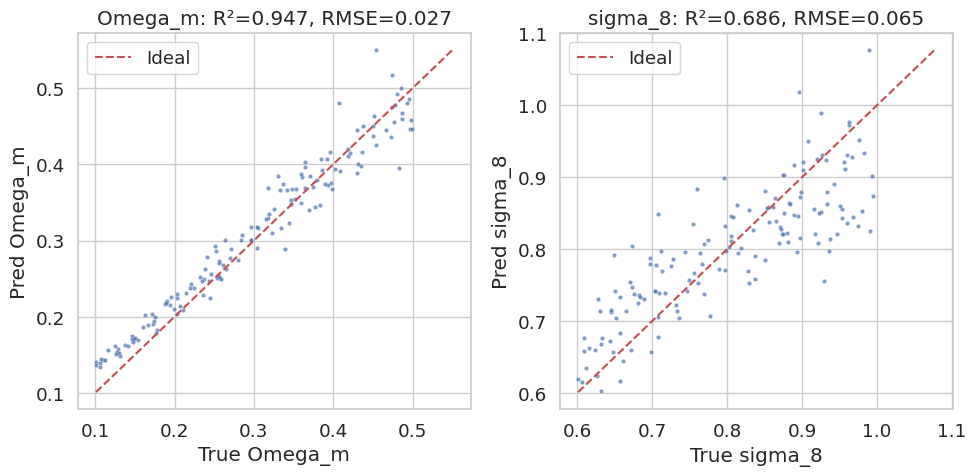

In [6]:
# =====================
# 5. Scatter plots (true vs pred)
# =====================
n_params = len(param_names)
fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 5))

if n_params == 1:
    axes = [axes]

for ax, true_col, pred_col, pname in zip(axes, param_cols, pred_cols, param_names):
    sns.scatterplot(x=pred_df[true_col], y=pred_df[pred_col], ax=ax, s=10, alpha=0.7)
    lims = [
        min(pred_df[true_col].min(), pred_df[pred_col].min()),
        max(pred_df[true_col].max(), pred_df[pred_col].max())
    ]
    ax.plot(lims, lims, "r--", label="Ideal")
    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel(f"Pred {pname}")
    ax.set_title(f"{pname}: R²={metrics_df[metrics_df['param']==pname]['R2'].values[0]:.3f}, "
                 f"RMSE={metrics_df[metrics_df['param']==pname]['RMSE'].values[0]:.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

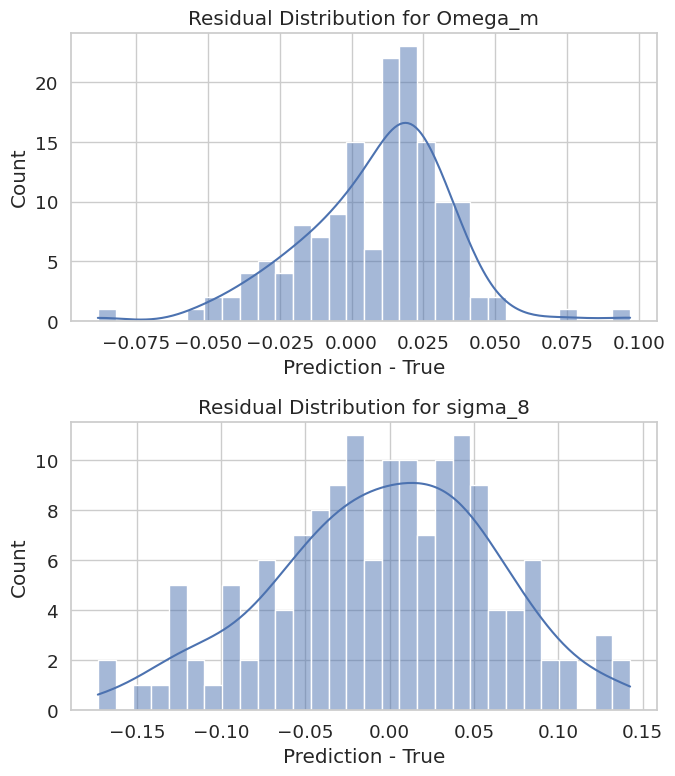

In [7]:
# =====================
# 6. Residual distribution
# =====================
fig, axes = plt.subplots(n_params, 1, figsize=(7, 4*n_params))
if n_params == 1:
    axes = [axes]

for ax, true_col, pred_col, pname in zip(axes, param_cols, pred_cols, param_names):
    residuals = pred_df[pred_col] - pred_df[true_col]
    sns.histplot(residuals, bins=30, kde=True, ax=ax)
    ax.set_title(f"Residual Distribution for {pname}")
    ax.set_xlabel("Prediction - True")

plt.tight_layout()
plt.show()


,param,R2,RMSE,MAE,Pearson_r,Spearman_rho,Bias(mean resid),Std(resid)
0,Omega_m,0.9474,0.0267,0.0216,0.9788,0.9819,0.0087,0.0253
1,sigma_8,0.6858,0.0648,0.0519,0.8307,0.8410,-0.0033,0.0649


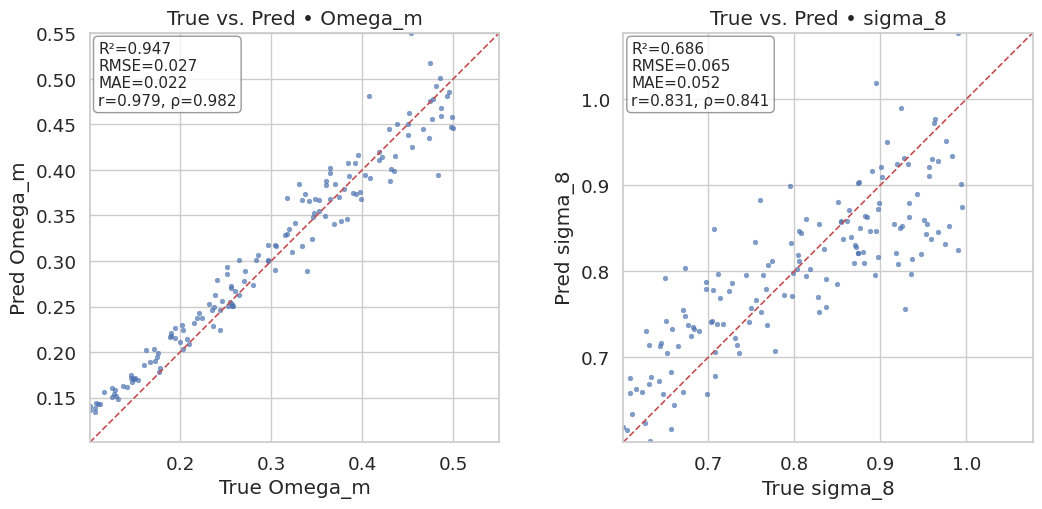

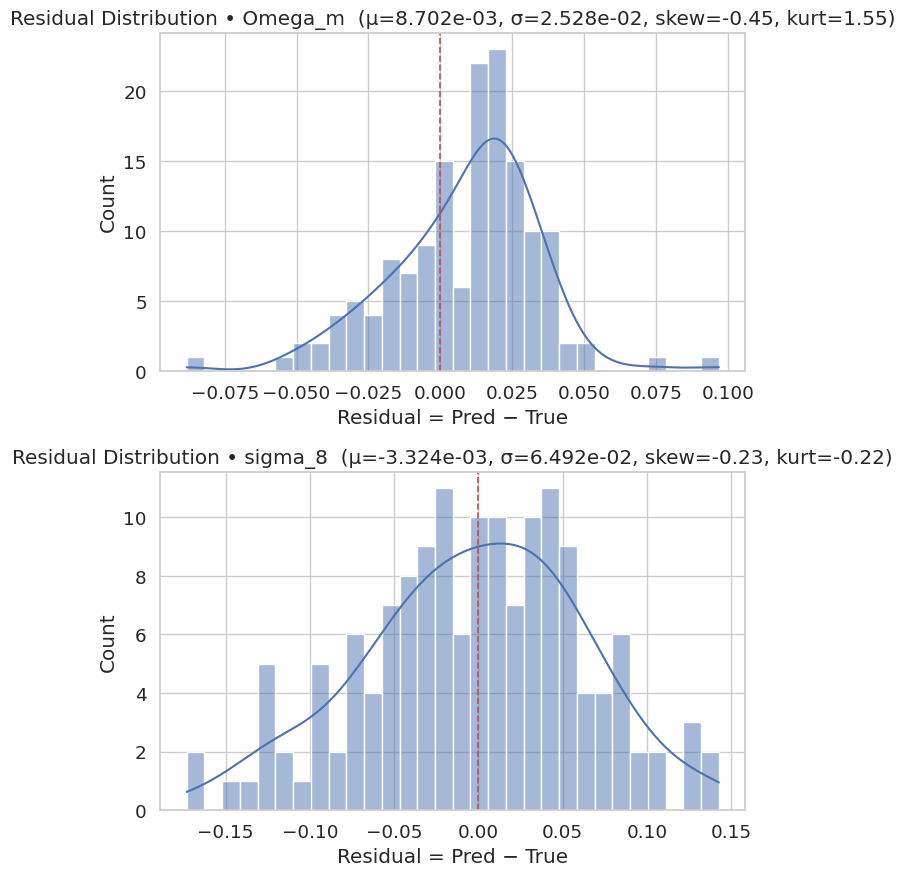

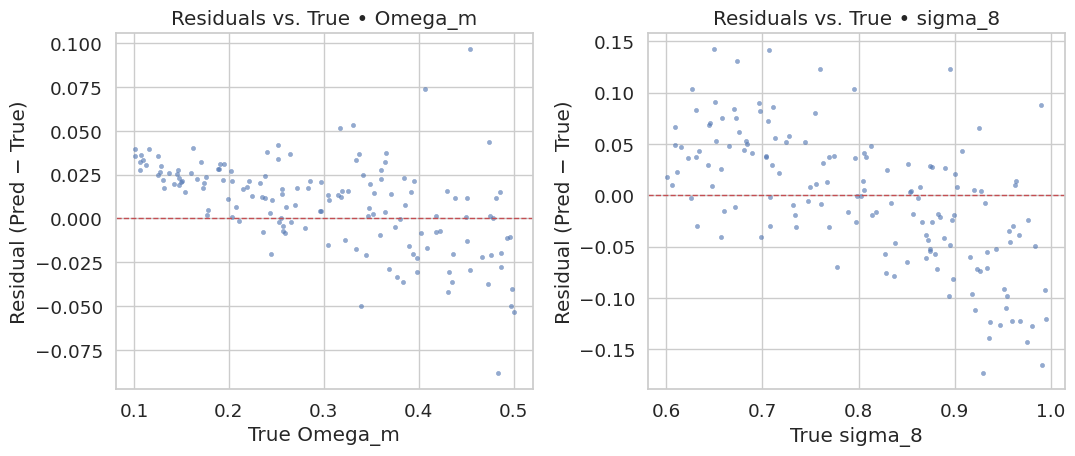

In [8]:
# =====================
# 4. Evaluation metrics (enhanced)
# =====================
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr, skew, kurtosis
import os

SAVE_DIR = "./unet/eval_figs/SIMBA_Mtot_20250819"  # <- 원하는 경로로
os.makedirs(SAVE_DIR, exist_ok=True)

def compute_metrics(pred_df, param_cols, pred_cols):
    rows = []
    for true_col, pred_col in zip(param_cols, pred_cols):
        pname = true_col.replace("true_", "")
        y_true = pred_df[true_col].values
        y_pred = pred_df[pred_col].values
        resid  = y_pred - y_true

        r2   = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        pr, _ = pearsonr(y_true, y_pred)
        sr, _ = spearmanr(y_true, y_pred)

        rows.append({
            "param": pname,
            "R2": r2,
            "RMSE": rmse,
            "MAE": mae,
            "Pearson_r": pr,
            "Spearman_rho": sr,
            "Bias(mean resid)": float(np.mean(resid)),
            "Std(resid)": float(np.std(resid, ddof=1))
        })
    return pd.DataFrame(rows)

metrics_df = compute_metrics(pred_df, param_cols, pred_cols)
display(metrics_df.round(4))
metrics_df.to_csv(os.path.join(SAVE_DIR, "metrics_summary.csv"), index=False)

# =====================
# 5. Scatter plots (true vs pred) with annotations
# =====================
n_params = len(param_names)
fig, axes = plt.subplots(1, n_params, figsize=(5.5*n_params, 5.2))
if n_params == 1:
    axes = [axes]

for ax, true_col, pred_col, pname in zip(axes, param_cols, pred_cols, param_names):
    y_true = pred_df[true_col].values
    y_pred = pred_df[pred_col].values

    sns.scatterplot(x=y_true, y=y_pred, ax=ax, s=12, alpha=0.7, edgecolor=None)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="1:1")

    # equal aspect & margins
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')

    # metrics text box
    m = metrics_df[metrics_df["param"] == pname].iloc[0]
    txt = (f"R²={m['R2']:.3f}\nRMSE={m['RMSE']:.3f}\nMAE={m['MAE']:.3f}\n"
           f"r={m['Pearson_r']:.3f}, ρ={m['Spearman_rho']:.3f}")
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8), fontsize=11)

    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel(f"Pred {pname}")
    ax.set_title(f"True vs. Pred • {pname}")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "scatter_true_vs_pred.png"), dpi=200)
plt.show()

# =====================
# 6. Residual distribution (histogram + KDE) with moments
# =====================
fig, axes = plt.subplots(n_params, 1, figsize=(7, 4.5*n_params))
if n_params == 1:
    axes = [axes]

for ax, true_col, pred_col, pname in zip(axes, param_cols, pred_cols, param_names):
    resid = pred_df[pred_col].values - pred_df[true_col].values
    sns.histplot(resid, bins=30, kde=True, ax=ax)
    ax.axvline(0.0, color="r", lw=1.2, ls="--")
    mu, sd = np.mean(resid), np.std(resid, ddof=1)
    sk, kt = skew(resid, nan_policy="omit"), kurtosis(resid, nan_policy="omit")
    ax.set_title(f"Residual Distribution • {pname}  (μ={mu:.3e}, σ={sd:.3e}, skew={sk:.2f}, kurt={kt:.2f})")
    ax.set_xlabel("Residual = Pred − True")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "residual_hist.png"), dpi=200)
plt.show()

# =====================
# 7. Residuals vs. True (heteroscedasticity/bias check)
# =====================
fig, axes = plt.subplots(1, n_params, figsize=(5.5*n_params, 4.8))
if n_params == 1:
    axes = [axes]

for ax, true_col, pred_col, pname in zip(axes, param_cols, pred_cols, param_names):
    y_true = pred_df[true_col].values
    resid  = pred_df[pred_col].values - y_true
    sns.scatterplot(x=y_true, y=resid, ax=ax, s=10, alpha=0.6, edgecolor=None)
    ax.axhline(0.0, color="r", lw=1.0, ls="--")
    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel("Residual (Pred − True)")
    ax.set_title(f"Residuals vs. True • {pname}")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "residuals_vs_true.png"), dpi=200)
plt.show()


In [9]:
import glob
import os

def get_latest_file(base_dir: str, filename: str) -> str:
    """주어진 base_dir 하위의 가장 최신 날짜 폴더에서 filename 경로 반환"""
    subdirs = glob.glob(os.path.join(base_dir, "20*"))  # 20으로 시작하는 날짜 폴더
    if not subdirs:
        raise FileNotFoundError(f"No subdirectories found in {base_dir}")
    latest_dir = max(subdirs, key=os.path.getmtime)
    return os.path.join(latest_dir, filename)

# -------- 사용 예시 --------
# 최신 모델 자동 선택
model_path = get_latest_file("./unet/runs/SIMBA_Mtot", "best_model.pt")

# CAMELS TNG 데이터셋 (날짜폴더 아님 → 그대로 사용)
tng_imgs_path = "./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy"
tng_params_path = "./data/CAMELS_multifield/params_LH_IllustrisTNG.txt"

# 최신 training log 자동 선택
log_path = get_latest_file("./unet/runs/SIMBA_Mtot", "training_log.csv")

# 최신 prediction 결과 자동 선택
pred_path = get_latest_file("./unet/predictions/SIMBA_Mtot", "predictions.csv")

print("Latest model        :", model_path)
print("TNG images          :", tng_imgs_path)
print("TNG params          :", tng_params_path)
print("Latest training log :", log_path)
print("Latest predictions  :", pred_path)


Latest model        : ./unet/runs/SIMBA_Mtot/20250819_201537/best_model.pt
TNG images          : ./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy
TNG params          : ./data/CAMELS_multifield/params_LH_IllustrisTNG.txt
Latest training log : ./unet/runs/SIMBA_Mtot/20250819_201537/training_log.csv
Latest predictions  : ./unet/predictions/SIMBA_Mtot/20250819_201723/predictions.csv


TNG dataset loaded: X=(1000, 15, 256, 256), y=(1000, 2)


,true_Omega_m,pred_Omega_m,true_sigma8,pred_sigma8
0,0.3090,0.336910,0.9790,0.951512
1,0.3026,0.316084,0.9394,0.955522
2,0.4282,0.451789,0.7530,0.880807
3,0.1906,0.181196,0.6286,0.714866
4,0.1382,0.136260,0.6874,0.803130


=== Cross-simulation Evaluation (Train=SIMBA, Test=TNG) ===


,param,R2,RMSE,MAE,Pearson_r,Spearman_rho,Bias(mean resid),Std(resid)
0,Omega_m,0.9325,0.0300,0.0206,0.9739,0.9784,0.0091,0.0286
1,sigma8,0.5518,0.0773,0.0633,0.8117,0.8340,0.0370,0.0679


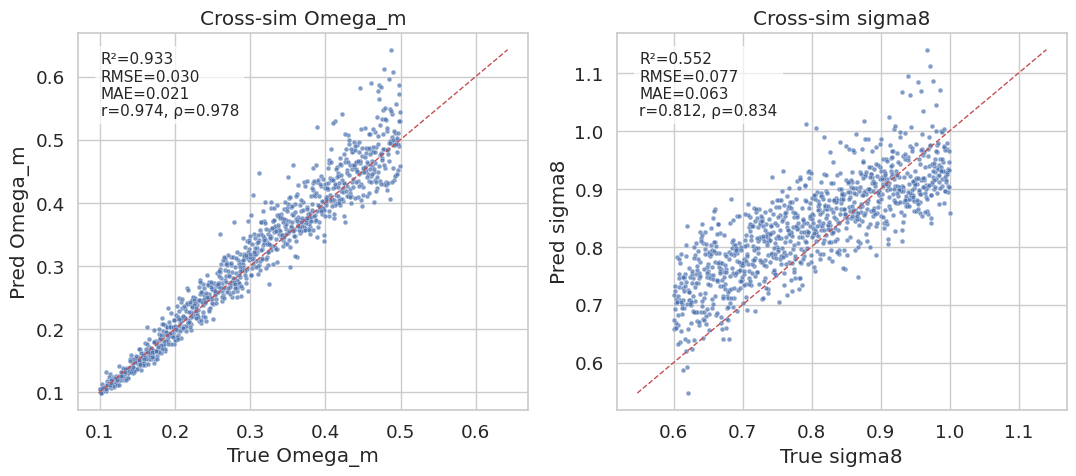

In [10]:
# =====================
# Cross-simulation Evaluation
# =====================
import torch

# 경로 설정
#model_path = "./unet/runs/SIMBA_Mtot/20250819_141929/best_model.pt"   # <- SIMBA로 학습된 모델
#tng_imgs_path = "./data/CAMELS_multifield/Maps_Mtot_IllustrisTNG_LH_z=0.00.npy"
#tng_params_path = "./data/CAMELS_multifield/params_LH_IllustrisTNG.txt"

# 1) TNG 데이터 로드
X_tng = np.load(tng_imgs_path)   # (N,15,256,256) or (N*15,256,256)
y_tng = np.loadtxt(tng_params_path)  # (N,6) or (6,N)

# 모양 보정 (당신의 train.py와 동일 로직)
if y_tng.ndim == 2 and y_tng.shape[1] == X_tng.shape[0]:
    y_tng = y_tng.T
y_tng = y_tng[:, :2].astype(np.float32)

if X_tng.ndim == 3 and X_tng.shape[0] % 15 == 0:
    n_sims = X_tng.shape[0] // 15
    X_tng = X_tng.reshape(n_sims, 15, X_tng.shape[1], X_tng.shape[2])
X_tng = X_tng.astype(np.float32)

print(f"TNG dataset loaded: X={X_tng.shape}, y={y_tng.shape}")

# 2) 모델 로드
from unet.model import UNetEncoderRegressor
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNetEncoderRegressor(in_channels=15, out_dim=2).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 3) 예측 실행
with torch.no_grad():
    preds_tng = []
    for i in range(0, len(X_tng), 32):   # 배치 단위 (32개씩)
        batch = torch.tensor(X_tng[i:i+32], dtype=torch.float32).to(device)
        out = model(batch).cpu().numpy()
        preds_tng.append(out)
    preds_tng = np.vstack(preds_tng)

# 4) 결과 DataFrame으로 정리
cross_df = pd.DataFrame({
    "true_Omega_m": y_tng[:,0],
    "pred_Omega_m": preds_tng[:,0],
    "true_sigma8":  y_tng[:,1],
    "pred_sigma8":  preds_tng[:,1],
})
display(cross_df.head())

# 5) 기존 평가 코드 재사용
param_cols = [c for c in cross_df.columns if c.startswith("true_")]
pred_cols  = [c for c in cross_df.columns if c.startswith("pred_")]
param_names = [c.replace("true_", "") for c in param_cols]

# 메트릭 계산
metrics_cross = compute_metrics(cross_df, param_cols, pred_cols)
print("=== Cross-simulation Evaluation (Train=SIMBA, Test=TNG) ===")
display(metrics_cross.round(4))

# =====================
# Cross-simulation Scatter with Metrics Text
# =====================
n_params = len(param_names)
fig, axes = plt.subplots(1, n_params, figsize=(5.5*n_params, 5))
if n_params == 1: 
    axes = [axes]

for ax, pname, tcol, pcol in zip(axes, param_names, param_cols, pred_cols):
    # scatter
    sns.scatterplot(x=cross_df[tcol], y=cross_df[pcol], s=12, alpha=0.7, ax=ax)

    # y=x reference line
    lims = [min(cross_df[tcol].min(), cross_df[pcol].min()), 
            max(cross_df[tcol].max(), cross_df[pcol].max())]
    ax.plot(lims, lims, "r--", lw=1.0)

    # metrics 불러오기
    m = metrics_cross[metrics_cross["param"] == pname].iloc[0]
    txt = (f"R²={m['R2']:.3f}\nRMSE={m['RMSE']:.3f}\nMAE={m['MAE']:.3f}\n"
           f"r={m['Pearson_r']:.3f}, ρ={m['Spearman_rho']:.3f}")

    # plot에 metrics 추가
    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            verticalalignment="top", horizontalalignment="left",
            fontsize=11, bbox=dict(boxstyle="round,pad=0.3", 
                                   facecolor="white", alpha=0.7))

    # labels & title
    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel(f"Pred {pname}")
    ax.set_title(f"Cross-sim {pname}")

plt.tight_layout()
plt.show()


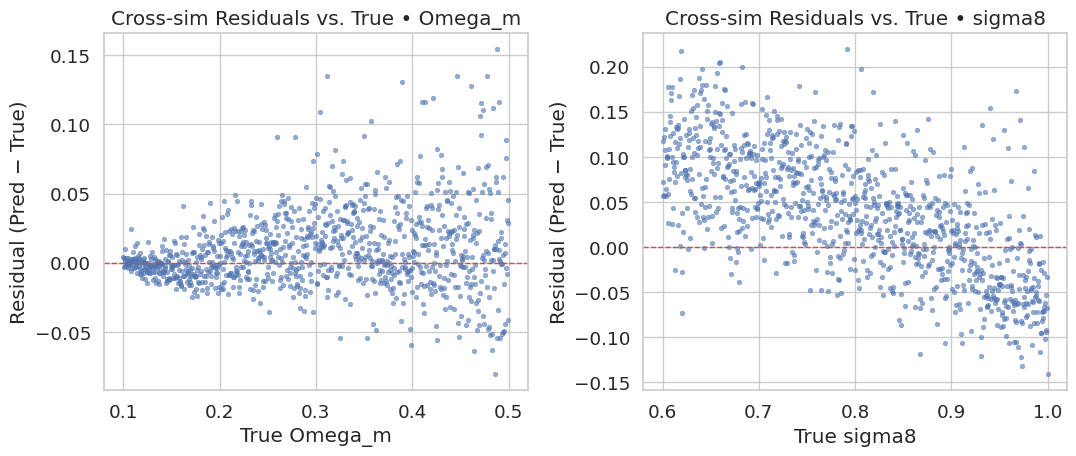

In [11]:
# =====================
# 7. Residuals vs. True (heteroscedasticity/bias check) for cross-sim
# =====================
fig, axes = plt.subplots(1, n_params, figsize=(5.5*n_params, 4.8))
if n_params == 1:
    axes = [axes]

for ax, pname, tcol, pcol in zip(axes, param_names, param_cols, pred_cols):
    y_true = cross_df[tcol].values
    resid  = cross_df[pcol].values - y_true
    sns.scatterplot(x=y_true, y=resid, s=12, alpha=0.6, ax=ax, edgecolor=None)
    ax.axhline(0.0, color="r", lw=1.0, ls="--")
    ax.set_xlabel(f"True {pname}")
    ax.set_ylabel("Residual (Pred − True)")
    ax.set_title(f"Cross-sim Residuals vs. True • {pname}")

plt.tight_layout()
plt.show()
